# Reto de Vision: Clasificacion de Productos con CNN

## Notebook 1 - Introduccion a las redes convolucionales y preparacion de datos

### Contexto del reto

Trabajas para una empresa de e-commerce de moda. Cada dia se suben miles de fotos de productos nuevos (playeras, pantalones, zapatos, bolsos, etc.) y alguien tiene que revisar cada imagen para asignarle una categoria. Esto es lento, caro y con errores humanos.

Tu mision, a lo largo de estas tres sesiones, es construir una Red Neuronal Convolucional (CNN) capaz de clasificar automaticamente estas imagenes.

### Objetivos de esta sesion

- Entender por que las redes densas que usamos la semana pasada no son la mejor opcion para trabajar con imagenes.
- Entender de forma intuitiva que hace una capa `Conv2D` (convolucion) y una capa `MaxPooling2D` (pooling).
- Cargar el dataset `Fashion MNIST`, explorarlo y dejarlo listo (normalizado y con la forma correcta) para poder entrenar una CNN en la proxima sesion.

En esta sesion no vamos a entrenar todavia ningun modelo de CNN. Vamos a construir la intuicion y a preparar los datos. El entrenamiento llega en el notebook 2.

## 1. Repaso rapido: lo que haciamos hasta ahora

La semana pasada trabajamos con datos tabulares: cada fila era una observacion y cada columna una feature (numeros). Armamos redes densas (`Dense`) donde cada neurona esta conectada con todas las neuronas de la capa anterior.

Una imagen tambien se puede ver como un monton de numeros: cada pixel tiene un valor. Entonces, en teoria, podriamos "aplanar" la imagen (convertirla en un vector largo de pixeles) y meterla a una red densa como las que ya conocemos.

El problema es que al aplanar la imagen perdemos la informacion espacial: la red ya no sabe que un pixel esta al lado de otro, arriba, abajo, etc. Ademas, una imagen de tamano razonable (por ejemplo 224x224x3) aplanada da mas de 150,000 valores de entrada, lo que genera una cantidad enorme de parametros si usamos solo capas densas.

Las CNN (Convolutional Neural Networks) fueron diseñadas justamente para resolver este problema: en vez de conectar cada pixel con cada neurona, usan pequeños "filtros" que recorren la imagen y detectan patrones locales (bordes, texturas, formas), respetando la estructura espacial.

## 2. La idea central de una CNN: la convolucion

Una capa `Conv2D` no mira toda la imagen de golpe. Usa un **filtro** (tambien llamado **kernel**), que es una pequeña matriz de numeros (por ejemplo 3x3), y la va deslizando sobre la imagen. En cada posicion, multiplica los valores del filtro con los pixeles que tiene debajo y suma el resultado. Ese unico numero resultante se guarda en una nueva matriz, que llamamos **feature map** (mapa de caracteristicas).

Cada filtro se especializa en detectar un patron distinto: uno puede activarse fuerte cuando encuentra un borde vertical, otro un borde horizontal, otro una textura, etc. Durante el entrenamiento, la red **aprende sola** cuales son los valores de esos filtros; nosotros no los definimos a mano.

Para entender bien la mecanica, vamos a programar una convolucion "a mano" con numpy, usando una imagen muy simple y un filtro fijo que nosotros elegimos (un detector de bordes verticales clasico).

### Que vamos a programar

1. Crear una imagen de 6x6 muy simple: la mitad izquierda con valores altos (por ejemplo 10) y la mitad derecha con valores bajos (0). Esto simula un borde vertical bien marcado.
2. Definir un filtro (kernel) de 3x3 que sea un detector de bordes verticales, por ejemplo:

```
[[ 1, 0, -1],
 [ 1, 0, -1],
 [ 1, 0, -1]]
```

3. Deslizar el filtro sobre la imagen (sin salirse de los bordes) y, en cada posicion, calcular la suma de la multiplicacion elemento a elemento entre el filtro y el pedazo de imagen que tiene debajo.
4. Guardar cada resultado en una matriz de salida (el feature map) y mostrarla.

Nota: cuando el filtro se mueve de a un pixel por vez decimos que el **stride** es 1. Si ademas no agregamos ningun borde extra de relleno alrededor de la imagen, decimos que no hay **padding**; por eso el feature map de salida es mas chico que la imagen de entrada.

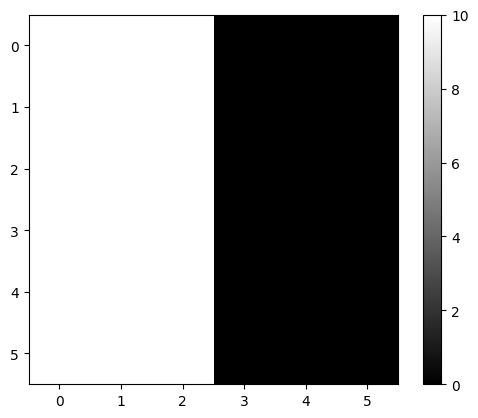

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Imagen simple 6x6: mitad izquierda "clara", mitad derecha "oscura"
imagen = np.array([
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
])

plt.imshow(imagen, cmap="gray")  # Mostramos el arreglo como una imagen en escala de grises
plt.colorbar()
plt.show()

In [2]:
# Filtro (kernel) detector de bordes verticales
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
])

alto_salida = imagen.shape[0] - kernel.shape[0] + 1  # Calculamos la altura del feature map
# ---> el kernel puede ocupar 4 posiciones verticales diferentes.

ancho_salida = imagen.shape[1] - kernel.shape[1] + 1  # Calculamos el ancho del feature map
# ---> el kernel puede ocupar 4 posiciones horizontal diferentes.

feature_map = np.zeros((alto_salida, ancho_salida))  # Creamos una matriz de ceros para guardar los resultados de la convolución

for i in range(alto_salida):  # Recorremos las filas de la imagen donde el kernel puede posicionarse
    for j in range(ancho_salida):  # Recorremos las columnas de la imagen donde el kernel puede posicionarse
        region = imagen[i:i + kernel.shape[0], j:j + kernel.shape[1]]  # Extraemos una región de la imagen del mismo tamaño que el kernel
        feature_map[i, j] = np.sum(region * kernel)  # Multiplicamos elemento por elemento y sumamos para obtener el valor del píxel de salida

print("Imagen original:")
print(imagen)
print("\nFeature map (resultado de la convolucion):")
print(feature_map)

Imagen original:
[[10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]]

Feature map (resultado de la convolucion):
[[ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]]


**kernel funcionan como weights**

Tenemos una pequeña región de la imagen y un kernel:

$$
\begin{bmatrix}
10 & 10 & 0 \\
10 & 10 & 0 \\
10 & 10 & 0
\end{bmatrix}
\times
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
$$
  
  
El primer bloque contiene los **pixel values** y el segundo bloque contiene los **weights** del kernel.

Multiplicamos cada elemento por su correspondiente **weight** y después sumamos todos los resultados.

$$
(10\times1) + (10\times0) + (0\times-1)
+ (10\times1) + (10\times0) + (0\times-1)
+ (10\times1) + (10\times0) + (0\times-1)
$$

El resultado es un único valor que se guarda en el **feature map**.  

Durante el training, la CNN aprende y actualiza estos weights para que el kernel pueda detectar features útiles, como edges, textures o patterns.

### Que observamos

Fijate que la columna del medio del feature map tiene valores muy altos (positivos o negativos segun como definiste el filtro). Eso es justamente la zona donde la imagen pasa de "clara" a "oscura", es decir, el borde vertical. El filtro detecto exactamente el patron para el que fue diseñado.

En una CNN real, la capa `Conv2D` no aplica un solo filtro sino varios en paralelo (por ejemplo 32 filtros), y cada uno aprende a detectar un patron distinto. El resultado no es un solo feature map sino una pila de varios feature maps, uno por filtro.

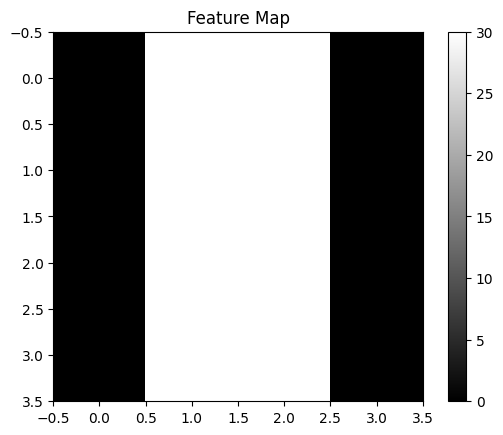

In [3]:
plt.imshow(feature_map, cmap="gray")  # Mostramos el feature map como una imagen en escala de grises
plt.title("Feature Map")
plt.colorbar()
plt.show()

Exploremos un caso a donde no hay vertical edges

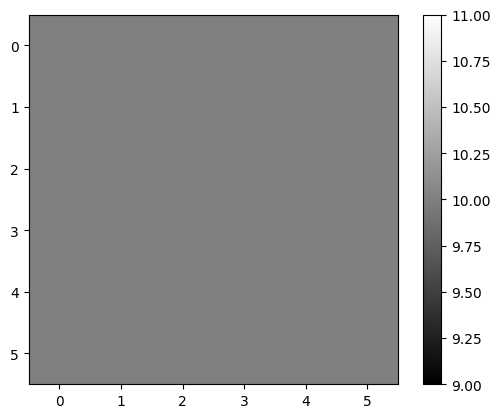

In [4]:
# Creamos una imagen uniforme de 6x6 donde todos los píxeles tienen el mismo valor (NO VERTICAL EDGE TO BE DETECTED)
imagen_uniforme = np.array([
    [10, 10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10, 10],
])

plt.imshow(imagen_uniforme, cmap="gray")  # Mostramos el arreglo como una imagen en escala de grises
plt.colorbar()
plt.show()

In [7]:
# Definimos el mismo kernel para detectar vertical edges
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
])

# Calculamos el tamaño del output feature map
alto_salida = imagen_uniforme.shape[0] - kernel.shape[0] + 1
ancho_salida = imagen_uniforme.shape[1] - kernel.shape[1] + 1

# Creamos una matriz para almacenar el resultado de la convolución
feature_map_uni = np.zeros((alto_salida, ancho_salida))

# Aplicamos la convolución
for i in range(alto_salida):  # Recorremos las filas de la imagen
    for j in range(ancho_salida):  # Recorremos las columnas de la imagen
        region = imagen_uniforme[i:i + 3, j:j + 3]  # Extraemos una región de 3x3
        feature_map_uni[i, j] = np.sum(region * kernel)  # Multiplicamos elemento por elemento y sumamos los resultados

# Mostramos la imagen y el resultado
print("Imagen uniforme:")
print(imagen_uniforme)

print("\nFeature map:")
print(feature_map_uni)

Imagen uniforme:
[[10 10 10 10 10 10]
 [10 10 10 10 10 10]
 [10 10 10 10 10 10]
 [10 10 10 10 10 10]
 [10 10 10 10 10 10]
 [10 10 10 10 10 10]]

Feature map:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


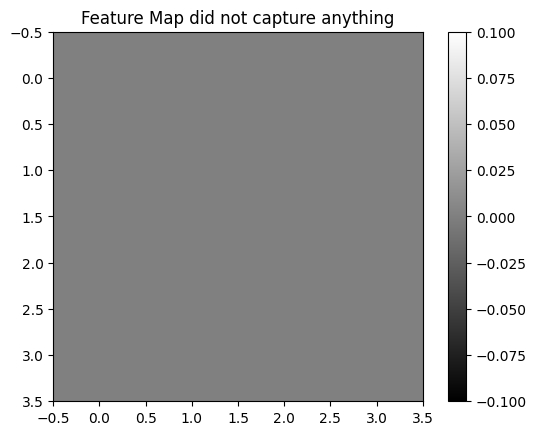

In [8]:
plt.imshow(feature_map_uni, cmap="gray")  # Mostramos el feature map como una imagen en escala de grises
plt.title("Feature Map did not capture anything")
plt.colorbar()
plt.show()

## 3. Reduciendo la informacion: Pooling

Despues de aplicar la convolucion, normalmente agregamos una capa de **pooling**, siendo `MaxPooling2D` la mas comun. Su trabajo es simple: dividir el feature map en pequeños bloques (por ejemplo de 2x2) y quedarse solo con el valor mas alto de cada bloque.

Esto tiene varias ventajas:

- Reduce el tamaño de los datos (menos calculo en las siguientes capas).
- Se queda con la informacion mas relevante (el valor mas fuerte de cada zona) y descarta detalles finos que no aportan mucho.
- Ayuda a que el modelo sea un poco mas tolerante a pequeños desplazamientos del patron dentro de la imagen (si el borde se mueve un pixel, el maximo de la zona probablemente sigue siendo el mismo).

Vamos a aplicar un max pooling de 2x2 (stride 2) sobre el `feature_map` que acabamos de calcular.

### Que vamos a programar

1. Tomar el `feature_map` de 4x4 obtenido antes.
2. Dividirlo en bloques de 2x2 sin que se superpongan.
3. Quedarnos con el maximo de cada bloque.
4. Guardar los resultados en una matriz de salida mas chica (2x2) y mostrarla.

In [9]:
tam_bloque = 2  # Definimos el tamaño del bloque para aplicar MaxPooling (2x2)

alto_pool = feature_map.shape[0] // tam_bloque  # Calculamos la altura del output después del pooling
ancho_pool = feature_map.shape[1] // tam_bloque  # Calculamos el ancho del output después del pooling
# "//" divide dos números y redondea el resultado hacia abajo al número entero más cercano.

pooled = np.zeros((alto_pool, ancho_pool))  # Creamos una matriz para almacenar el resultado del MaxPooling

for i in range(alto_pool):  # Recorremos las filas del output
    for j in range(ancho_pool):  # Recorremos las columnas del output
        region = feature_map[
            i * tam_bloque:(i + 1) * tam_bloque,
            j * tam_bloque:(j + 1) * tam_bloque
        ]  # Extraemos un bloque 2x2 del feature map

        pooled[i, j] = np.max(region)  # Guardamos el valor máximo del bloque en el output

print("Feature map antes del pooling:")  # Mostramos el feature map original
print(feature_map)

print("\nResultado despues de MaxPooling 2x2:")  # Mostramos el output después del MaxPooling
print(pooled)

Feature map antes del pooling:
[[ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]
 [ 0. 30. 30.  0.]]

Resultado despues de MaxPooling 2x2:
[[30. 30.]
 [30. 30.]]


Observa como la matriz paso de 4x4 a 2x2, pero la informacion importante (donde estaba el borde) se sigue viendo claramente. Esta es la idea que vamos a repetir varias veces dentro de una CNN: convolucion para detectar patrones, pooling para resumir y reducir tamaño, y asi sucesivamente.

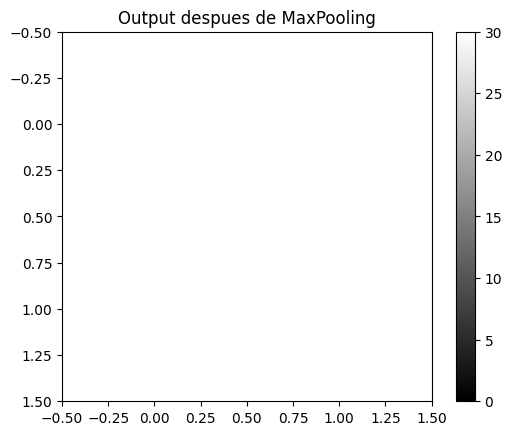

In [10]:
plt.imshow(pooled, cmap="gray", vmin=feature_map.min(), vmax=feature_map.max())  # Usamos la misma escala que el feature map, para poder comparar
plt.title("Output despues de MaxPooling")
plt.colorbar()
plt.show()

### Por que se ve de un solo color

La imagen con la que arrancamos era tan simple (un solo borde vertical, sin ningun otro detalle) que el `feature_map` termino teniendo el mismo valor alto (30) en toda la franja central. Al aplicar el pooling sobre esa franja, el resultado tambien queda casi uniforme: por eso el bloque se ve casi de un solo color, no porque haya un error.

Esto nos deja una leccion importante: con una imagen tan basica es dificil apreciar bien que tanto detalle conserva (o pierde) el pooling. Repitamos exactamente el mismo proceso -- mismo kernel, mismo pooling -- pero sobre un icono con mas estructura, para ver la diferencia.

## Repitiendo el proceso con una foto real

Ahora vamos a repetir exactamente el mismo proceso -- convolucion con el mismo kernel, y despues max pooling -- pero sobre una foto de verdad, no un dibujo hecho a mano.

Vamos a usar `camera()`, una imagen clasica en escala de grises que viene incluida en la libreria `scikit-image` (no hace falta descargar nada de internet, viene guardada dentro de la libreria). Es una foto que se usa desde hace decadas para enseñar procesamiento de imagenes, asi que es un buen puente antes de pasar a Fashion MNIST.

Shape: (512, 512)
Tipo de dato: uint8
Valor minimo: 0 - Valor maximo: 255


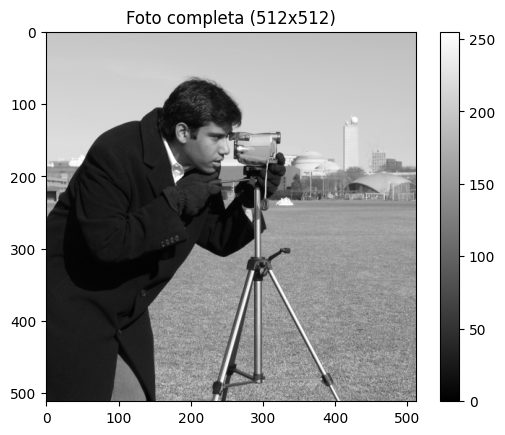

In [ ]:
from skimage import data

foto_completa = data.camera()  # Imagen real en escala de grises, 512x512

print("Shape:", foto_completa.shape)
print("Tipo de dato:", foto_completa.dtype)
print("Valor minimo:", foto_completa.min(), "- Valor maximo:", foto_completa.max())

plt.imshow(foto_completa, cmap="gray")
plt.title("Foto completa (512x512)")
plt.colorbar()
plt.show()

### Por que recortamos un pedazo

La imagen completa es de 512x512 pixeles: 512 - 3 + 1 = 510 posiciones distintas en cada eje, lo que da mas de 260,000 posiciones donde el kernel se puede colocar. Nuestro loop escrito a mano en Python (sin las optimizaciones internas que trae Keras) funcionaria pero seria lento y, ademas, un feature map de 510x510 es demasiado grande para interpretar a simple vista.

Por eso vamos a recortar un pedazo pequeño y reconocible de la foto (la camara que sostiene el fotografo) antes de aplicar la convolucion, igual que si hicieramos zoom sobre una zona interesante de la imagen.

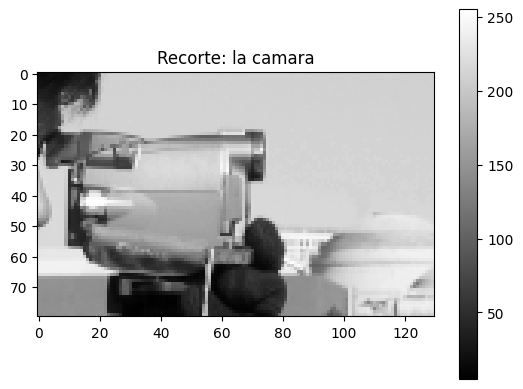

In [ ]:
recorte = foto_completa[120:200, 250:380]  # Recortamos un pedazo de 80x130: la camara

plt.imshow(recorte, cmap="gray")
plt.title("Recorte: la camara")
plt.colorbar()
plt.show()

### Aplicando el mismo kernel

Vamos a reutilizar el mismo `kernel` detector de bordes verticales que definimos al principio (no hace falta crear uno nuevo). El procedimiento es exactamente el mismo: deslizar el kernel sobre la imagen, multiplicar elemento a elemento con la region que tiene debajo, sumar, y guardar ese numero en el `feature_map`.

### Que vamos a programar

Repite la misma logica de las secciones anteriores (el doble `for`, el calculo del `alto_salida` y `ancho_salida`, y la formula `np.sum(region * kernel)`), pero ahora usando `recorte` en vez de `imagen`.

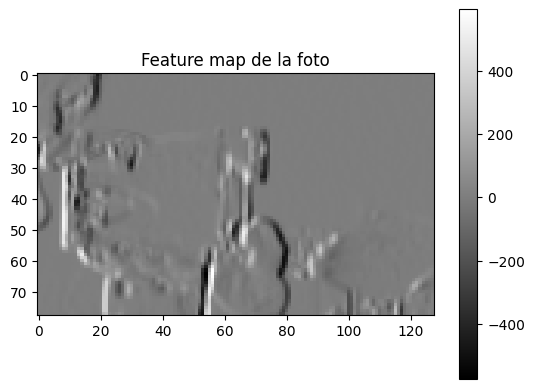

In [ ]:
alto_salida_foto = recorte.shape[0] - kernel.shape[0] + 1  # Altura del feature map
ancho_salida_foto = recorte.shape[1] - kernel.shape[1] + 1  # Ancho del feature map

feature_map_foto = np.zeros((alto_salida_foto, ancho_salida_foto))  # Matriz de ceros para guardar los resultados

for i in range(alto_salida_foto):  # Recorremos las filas donde el kernel puede posicionarse
    for j in range(ancho_salida_foto):  # Recorremos las columnas donde el kernel puede posicionarse
        region = recorte[i:i + kernel.shape[0], j:j + kernel.shape[1]]  # Region de la imagen del mismo tamano que el kernel
        feature_map_foto[i, j] = np.sum(region * kernel)  # Multiplicamos elemento por elemento y sumamos

plt.imshow(feature_map_foto, cmap="gray")  # Mostramos el feature map resultante
plt.title("Feature map de la foto")
plt.colorbar()
plt.show()

### Que observamos

A diferencia de los dos ejemplos anteriores, esta foto tiene textura, sombras y bordes en todas las direcciones, no solo un borde limpio. Aun asi, el patron se repite: los bordes mas parecidos a una linea vertical (por ejemplo los costados del cuerpo de la camara, o el contorno de la mano que la sostiene) generan valores fuertes (muy blancos o muy negros en el feature map), mientras que las zonas mas uniformes (como el fondo, sin cambios bruscos de tono) quedan practicamente en gris, cerca de 0.

Este mismo kernel no detecta bien los bordes horizontales (como la parte de arriba o abajo de la camara), por la misma razon que en el ejemplo anterior: fue diseñado especificamente para bordes verticales. Con una foto real se nota todavia mas claro por que una capa `Conv2D` necesita muchos filtros en paralelo (32, 64, o mas) para poder capturar todos los tipos de bordes y texturas que existen en una imagen del mundo real.

### Pooling sobre el nuevo feature map

Ahora repetimos el max pooling, otra vez con la misma logica de antes (bloques de 2x2, quedandonos con el maximo de cada bloque), pero sobre `feature_map_foto`.

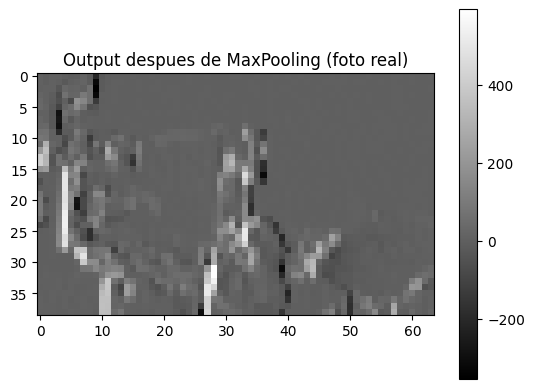

In [ ]:
tam_bloque_foto = 2  # Mismo tamano de bloque que usamos antes

alto_pool_foto = feature_map_foto.shape[0] // tam_bloque_foto  # Altura del output despues del pooling
ancho_pool_foto = feature_map_foto.shape[1] // tam_bloque_foto  # Ancho del output despues del pooling

pooled_foto = np.zeros((alto_pool_foto, ancho_pool_foto))  # Matriz para guardar el resultado del MaxPooling

for i in range(alto_pool_foto):  # Recorremos las filas del output
    for j in range(ancho_pool_foto):  # Recorremos las columnas del output
        region = feature_map_foto[
            i * tam_bloque_foto:(i + 1) * tam_bloque_foto,
            j * tam_bloque_foto:(j + 1) * tam_bloque_foto
        ]  # Bloque 2x2 del feature map
        pooled_foto[i, j] = np.max(region)  # Valor maximo del bloque

plt.imshow(pooled_foto, cmap="gray")
plt.title("Output despues de MaxPooling (foto real)")
plt.colorbar()
plt.show()

El feature map de 78x128 quedo reducido a 39x64 despues del pooling, pero la silueta general de la camara y de la mano se sigue reconociendo: se perdio resolucion (detalle fino), no la informacion importante.

Con estos ejemplos -- el borde perfecto dibujado a mano, el caso sin ningun borde, y ahora una foto real -- ya viste, paso a paso, que hace exactamente una capa `Conv2D` (detectar patrones locales con un filtro) y una capa `MaxPooling2D` (resumir y reducir tamano quedandose con lo mas fuerte de cada zona). Una CNN real repite esta misma pareja de operaciones varias veces seguidas, con muchos filtros en paralelo que la red aprende sola durante el entrenamiento, hasta llegar a reconocer objetos completos en fotos reales.

## 4. Fase 1: Preparando los datos - Fashion MNIST

Vamos a usar el dataset `Fashion MNIST`, que viene incluido directamente en Keras (no hace falta descargar nada de internet aparte). Contiene 70,000 imagenes en escala de grises de 28x28 pixeles, repartidas en 10 categorias de productos de moda: exactamente el tipo de problema que tiene nuestra empresa de e-commerce, solo que en una version simplificada y perfecta para aprender.

El dataset ya viene dividido en un set de entrenamiento (60,000 imagenes) y un set de prueba (10,000 imagenes).

### Que vamos a programar

Importar `tensorflow` y cargar el dataset usando `keras.datasets.fashion_mnist.load_data()`. Esta funcion devuelve dos tuplas: `(X_train, y_train)` y `(X_test, y_test)`.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Explorando la forma de los datos

Verificamos el `shape` para entender que estamos manipulando.

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


`X_train` tiene shape `(60000, 28, 28)`: son 60,000 imagenes, cada una de 28x28 pixeles. Todavia no tiene el canal de color, eso lo vamos a agregar mas adelante. `y_train` tiene shape `(60000,)`: es un numero (la etiqueta de la categoria) por cada imagen.

### Las categorias del dataset

Las etiquetas (`y_train`, `y_test`) son numeros del 0 al 9, cada uno representando una categoria de producto. Keras no nos da los nombres directamente, asi que los definimos nosotros mismos, en el orden oficial del dataset.

In [ ]:
class_names = [
    "Playera/Top", "Pantalon", "Sueter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Tenis", "Bolso", "Botin"
]

print("Etiqueta de la primera imagen de entrenamiento:", y_train[0])
print("Categoria correspondiente:", class_names[y_train[0]])

Etiqueta de la primera imagen de entrenamiento: 9
Categoria correspondiente: Botin


### Visualizando algunas imagenes

Antes de seguir, siempre es buena practica ver de verdad los datos con los que vamos a trabajar. Vamos a mostrar una cuadricula de 10 imagenes de `X_train`, cada una con su etiqueta como titulo.

Recuerda que cada imagen es una matriz de 28x28 con valores de pixel; para mostrarla usamos `plt.imshow(imagen, cmap="gray")`.

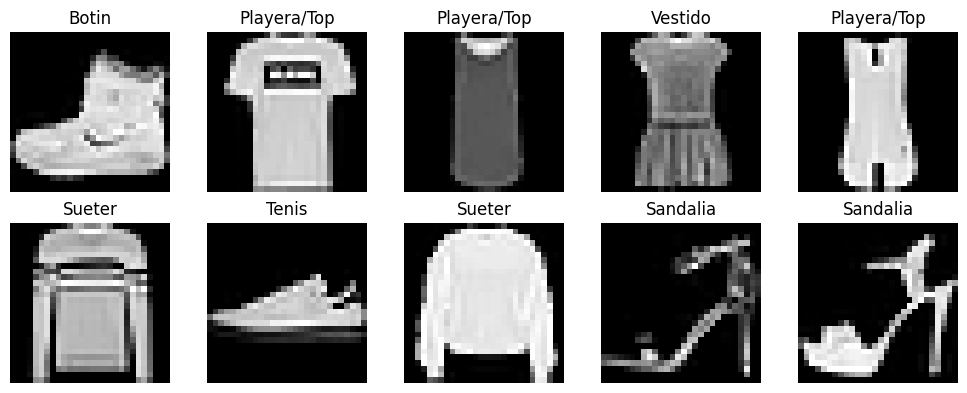

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Una observacion sobre los valores de pixel

Los valores de cada pixel van de 0 (negro) a 255 (blanco), porque cada imagen esta guardada como un array de enteros de 8 bits. Vamos a confirmarlo mirando el valor minimo y maximo de `X_train`.

In [ ]:
print("Valor minimo de pixel:", X_train.min())
print("Valor maximo de pixel:", X_train.max())
print("Tipo de dato:", X_train.dtype)

Valor minimo de pixel: 0
Valor maximo de pixel: 255
Tipo de dato: uint8


## 5. Normalizacion de pixeles

Al igual que con datos tabulares, las redes neuronales entrenan mejor y mas rapido cuando los valores de entrada estan en un rango chico, tipicamente entre 0 y 1. Como sabemos que los pixeles van de 0 a 255, la normalizacion es sencilla: dividimos todo entre 255.0.

### Que vamos a programar

Dividir `X_train` y `X_test` entre 255.0, guardando el resultado en las mismas variables (o en variables nuevas, como prefieras).

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Nuevo valor minimo:", X_train.min())
print("Nuevo valor maximo:", X_train.max())

Nuevo valor minimo: 0.0
Nuevo valor maximo: 1.0


In [ ]:
# verificamos un subset de pixel
X_train[1, :10, :10]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00392157, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.00392157, 0.        ,
        0.        , 0.        , 0.19215686, 0.53333333, 0.85882353],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.05490196, 0.69019608, 0.87058824, 0.87843137, 0.83137255],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.7372549 , 0.85882353, 0.78431373, 0.77647059, 0.79215686],
       [0.        , 0.        , 0.        , 0.        , 0.2       ,
        0.85882353, 0.78039216, 0.79607843, 0.79607843, 0.83137255],
       [0.        , 0.        , 0.        , 0.        , 0.45490196,
        0.88627451, 0.80784314, 0.8       , 0.81176471, 0.8       ],
       [0.        , 0.        , 0.        , 0.        , 0.78431373,
        0.87058824, 0.81960784, 0.79607843, 0.84313725, 0.78431373],
       [0.        , 0.        , 0.       

## 6. Reshape: agregando el canal de color

Las capas `Conv2D` de Keras esperan que la entrada tenga 4 dimensiones: `(batch, alto, ancho, canales)`. El `batch` es la cantidad de imagenes, y los `canales` indican cuantos valores hay por pixel (1 para escala de grises, 3 para RGB).

Ahora mismo `X_train` tiene shape `(60000, 28, 28)`: le falta la dimension de canales. Como Fashion MNIST es en escala de grises, ese canal vale 1.

### Que vamos a programar

Usar `.reshape()` para pasar `X_train` de `(60000, 28, 28)` a `(60000, 28, 28, 1)`, y lo mismo para `X_test`. Despues imprime los nuevos shapes para confirmar que quedaron correctos.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("Nuevo shape de X_train:", X_train.shape)
print("Nuevo shape de X_test:", X_test.shape)

Nuevo shape de X_train: (60000, 28, 28, 1)
Nuevo shape de X_test: (10000, 28, 28, 1)


## Resumen y proximos pasos

En esta sesion:

- Entendimos por que las CNN respetan la estructura espacial de una imagen en vez de aplanarla directamente.
- Programamos a mano una convolucion y un max pooling para ver exactamente que operacion hace cada una de estas capas.
- Vimos, de forma conceptual, en que se diferencian las RNN de las CNN y por que se usa cada una segun el tipo de dato.
- Cargamos, exploramos, normalizamos y le dimos la forma correcta (4D) al dataset `Fashion MNIST`.

En la proxima sesion vamos a usar `X_train`, `y_train`, `X_test` y `y_test` ya preparados para construir nuestra primera arquitectura de CNN real con capas `Conv2D`, `MaxPooling2D`, `Flatten` y `Dense`, compilarla y entrenarla.